
A knowledge graph is a structured representation of knowledge that captures relationships and entities in a way that allows machines to understand and reason about information in the context of natural language processing. This powerful concept has gained prominence in recent years because of the frequent rise of semantic web technologies and advancements in machine learning. Knowledge graphs in NLP aim to model real-world entities and the relationships between them, providing a contextual understanding of information extracted from text data. This enables more sophisticated and nuanced language understanding, making it a valuable tool for various NLP applications. In this article, we will discuss knowledge graphs and see the process of implementation.
What is a Knowledge graph?
A knowledge graph is a graph-based knowledge representation that connects entities through relationships. These graphs are useful as we can integrate the generated knowledge graph with natural language processing models for tasks like question answering, summarization, or context-aware language understanding.
Key Steps in Knowledge graph:
But to generate knowledge graphs, we need to perform several steps, which are discussed below:
1. Data Acquisition: Gathering relevant textual data from diverse sources, which could include books, articles, websites, or domain-specific documents.
2. Entity Recognition: Then we need to use NLP techniques to identify entities (e.g., people, organizations, locations) within the text. Named Entity Recognition (NER) is an advanced method for this step.
3. Relation Extraction: Determining the relationships between identified entities This can involve parsing the syntactic and semantic structure of sentences to extract meaningful connections, which is called relationship extraction.
4. Graph Construction: Finally, building a graph structure where entities are nodes and relationships are edges. This step involves organizing the extracted information into a coherent graph representation. For advanced cases, we can enhance the graph by incorporating additional information like entity attributes, sentiment analysis or contextual details derived from the text but that are very complex, time-consuming and costly tasks.
What are the benefits of building a knowledge graph?
Some of the key benefits of the Knowledge graph are as follows:
* Improved Language Understanding: Knowledge Graphs provide a structured representation of information, enabling machines to better understand the context and semantics of language.
* Enhanced Information Retrieval: The graph structure facilitates efficient and precise retrieval of relevant information, improving search capabilities and reducing ambiguity.
* Context-Aware Applications: Knowledge Graphs enable context-aware NLP applications by capturing relationships between entities, supporting tasks such as sentiment analysis, named entity disambiguation, and coreference resolution.
* Support for Complex Queries: With the rich structure of a Knowledge Graph, systems can handle complex queries involving multiple entities and relationships, contributing to more advanced language processing.
* Facilitation of Inference and Reasoning: The graph structure allows for reasoning and inference, enabling the system to draw logical conclusions and provide more accurate responses.
* Domain-Specific Insights: Tailoring Knowledge Graphs to specific domains results in a deeper understanding of subject matter, facilitating domain-specific insights and applications.
* Interoperability and Integration: Knowledge Graphs promote interoperability by providing a common framework for integrating information from diverse sources, fostering collaboration between different systems and applications.



In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from nltk import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk

In [2]:
from nltk.corpus import wordnet

TypeError: WordNetCorpusReader.synsets() missing 1 required positional argument: 'lemma'

In [3]:
tractor = wordnet.synsets("synsets")

In [4]:
tractor

[Synset('synset.n.01')]

In [5]:
[s.definition() for s in tractor]

['a set of one or more synonyms']

In [2]:
# Create a small custom dataset with sentences
data = {
    "sentence": [
        "Sandeep Jain founded GeeksforGeeks.",
        "GeeksforGeeks is also known as GFG.",
        "GeeksforGeeks is a website.",
        "Authors writes for GFG.",
    ],
    "source": ["Sandeep Jain", "GeeksforGeeks", "GeeksforGeeks", "Authors"],
    "target": ["GeeksforGeeks", "GFG", "website", "GFG"],
    "relation": ["founded", "known as", "is", "write for"],
}

df = pd.DataFrame(data)
df

,sentence,source,target,relation
0,Sandeep Jain founded GeeksforGeeks.,Sandeep Jain,GeeksforGeeks,founded
1,GeeksforGeeks is also known as GFG.,GeeksforGeeks,GFG,known as
2,GeeksforGeeks is a website.,GeeksforGeeks,website,is
3,Authors writes for GFG.,Authors,GFG,write for


In [3]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [4]:
def preprocess(text):
    return " ".join(
        [
            lemmatizer.lemmatize(word.lower())
            for word in word_tokenize(text)
            if word.isalnum() and word.lower() not in stop_words
        ]
    )


df["cleaned_sentence"] = df["sentence"].apply(preprocess)
df

,sentence,source,target,relation,cleaned_sentence
0,Sandeep Jain founded GeeksforGeeks.,Sandeep Jain,GeeksforGeeks,founded,sandeep jain founded geeksforgeeks
1,GeeksforGeeks is also known as GFG.,GeeksforGeeks,GFG,known as,geeksforgeeks also known gfg
2,GeeksforGeeks is a website.,GeeksforGeeks,website,is,geeksforgeeks website
3,Authors writes for GFG.,Authors,GFG,write for,author writes gfg


In [5]:
preprocess("Author's writes for GFG.")  # Just what?

'author writes gfg'

In [6]:
preprocess("Author's")

'author'

In [7]:
[
    lemmatizer.lemmatize(x)
    for x in word_tokenize("deven's")
    if x.isalnum() and x not in stop_words
]

['deven']

Knowlwdge Graph Edges adding loop
Now we will define a for loop to iterate over the dataset and extracting the subject, object and relationships from each sentences. This step is very important because here we will create the nodes of the graph and their corresponding relationships will create the edges of the graph.

In [8]:
G = nx.DiGraph()
for _, row in df.iterrows():
    source = row["source"]
    target = row["target"]
    relation = row["relation"]
    G.add_node(source)
    G.add_node(target)
    G.add_edge(source, target, relation=relation)

In [9]:
dict(G.degree)

{'Sandeep Jain': 1, 'GeeksforGeeks': 3, 'GFG': 2, 'website': 1, 'Authors': 1}

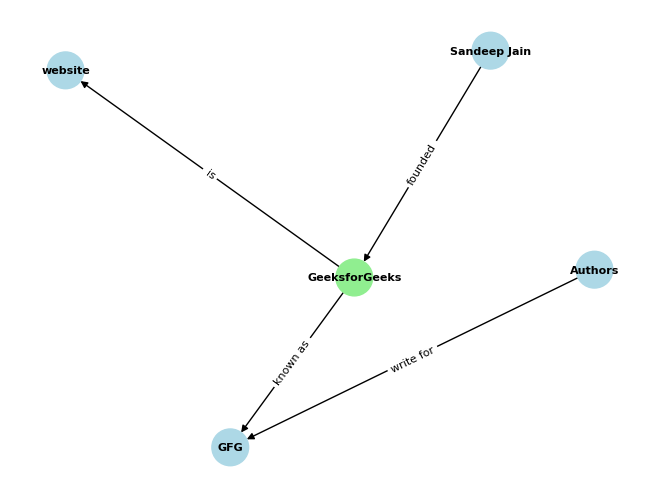

In [10]:
node_degrees = dict(G.degree)
node_colors = [
    "lightgreen" if degree == max(node_degrees.values()) else "lightblue"
    for degree in node_degrees.values()
]
pos = nx.spring_layout(G, seed=42, k=1.5)

labels = nx.get_edge_attributes(G, "relation")
nx.draw(
    G,
    pos,
    with_labels=True,
    font_weight="bold",
    node_size=700,
    node_color=node_colors,
    font_size=8,
    arrowsize=10,
)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=8)
plt.show()